# AML s26 - K-Means with Imbalanced Clusters

This notebook demonstrates a **weakness of k-means**: when one cluster is much larger than another, the algorithm tends to *split the large cluster* rather than correctly identifying the small one.

We create:
- **Cluster A** — 500 points (large)
- **Cluster B** — 10 points (small)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

np.random.seed(2)

### Create the imbalanced dataset

In [2]:
# Large cluster — 500 points centred at (0, 0)
large = np.random.normal(loc=[0, 0], scale=1.0, size=(500, 2))

# Small cluster — 10 points centred at (6, 6)
small = np.random.normal(loc=[4, 4], scale=0.4, size=(10, 2))

X = np.vstack([large, small])

# True labels (for reference only — k-means never sees these)
y_true = np.array([0] * 500 + [1] * 10)

print(f'Total points : {len(X)}')
print(f'Large cluster: {len(large)} points')
print(f'Small cluster: {len(small)} points')

Total points : 510
Large cluster: 500 points
Small cluster: 10 points


### Plot the raw data

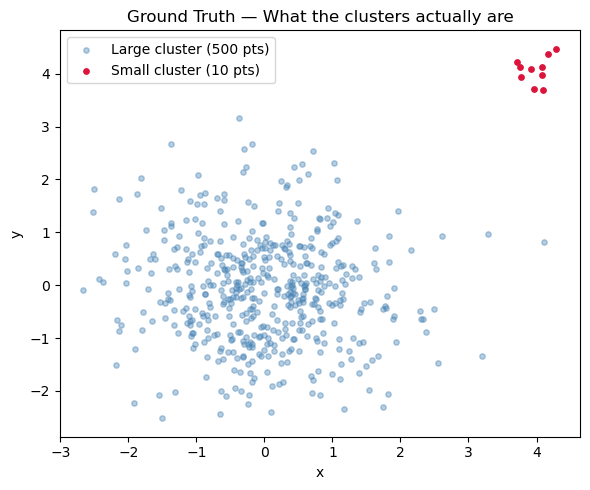

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(large[:, 0], large[:, 1], s=15, alpha=0.4, color='steelblue', label='Large cluster (500 pts)')
ax.scatter(small[:, 0], small[:, 1], s=15, color='crimson', label='Small cluster (10 pts)')
ax.set_title('Ground Truth — What the clusters actually are')
ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

### Run K-Means with k = 2

Intuitively we'd expect k-means to find the two groups above. Let's see what actually happens.

In [11]:
km = KMeans(n_clusters=2, random_state=0, n_init=10)
km.fit(X)
labels  = km.labels_
centers = km.cluster_centers_

print('Points assigned to each k-means cluster:')
for k in range(2):
    print(f'  Cluster {k}: {(labels == k).sum()} points')
print(f'\nCentroids:\n  C0 = {centers[0].round(2)}\n  C1 = {centers[1].round(2)}')

Points assigned to each k-means cluster:
  Cluster 0: 213 points
  Cluster 1: 297 points

Centroids:
  C0 = [1.02 0.42]
  C1 = [-0.62 -0.3 ]


c:\Users\tjmel\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


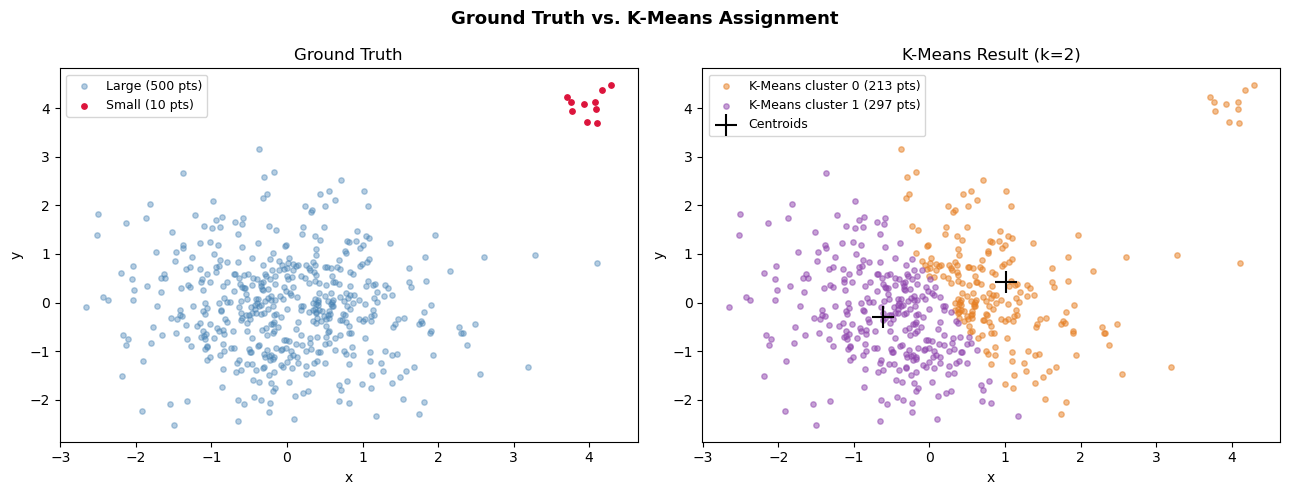

In [12]:
COLORS = ['#e67e22', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: ground truth ---
ax = axes[0]
ax.scatter(large[:, 0], large[:, 1], s=15, alpha=0.4, color='steelblue', label='Large (500 pts)')
ax.scatter(small[:, 0], small[:, 1], s=15, color='crimson', label='Small (10 pts)')
ax.set_title('Ground Truth')
ax.legend(fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')

# --- Right: k-means result ---
ax = axes[1]
for k in range(2):
    mask = labels == k
    ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.5,
               color=COLORS[k], label=f'K-Means cluster {k} ({mask.sum()} pts)')
ax.scatter(centers[:, 0], centers[:, 1],
           s=250, marker='+', color='black', zorder=5, label='Centroids')
ax.set_title('K-Means Result (k=2)')
ax.legend(fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Ground Truth vs. K-Means Assignment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Why did this happen?

K-means minimises **total inertia** (sum of squared distances to the nearest centroid). 

With 500 spread-out points, *splitting* the large blob reduces inertia more than isolating the 10 tiny points far away. The small cluster gets "absorbed" into whichever half of the large cluster is geometrically closest.

Let's measure the inertia of both possible assignments to confirm:

In [13]:
def manual_inertia(X, labels, centers):
    """Sum of squared distances from each point to its assigned centroid."""
    total = 0.0
    for k, c in enumerate(centers):
        pts = X[labels == k]
        total += ((pts - c) ** 2).sum()
    return total

# --- K-means solution ---
inertia_kmeans = manual_inertia(X, labels, centers)

# --- "Correct" solution (large=0, small=1) ---
correct_labels  = y_true.copy()
correct_centers = np.array([large.mean(axis=0), small.mean(axis=0)])
inertia_correct = manual_inertia(X, correct_labels, correct_centers)

print(f'Inertia — k-means solution : {inertia_kmeans:,.1f}')
print(f'Inertia — correct solution  : {inertia_correct:,.1f}')
print()
print('K-means found a LOWER inertia by splitting the large cluster.')
print('From its perspective, that is the better answer.')

Inertia — k-means solution : 940.8
Inertia — correct solution  : 1,008.5

K-means found a LOWER inertia by splitting the large cluster.
From its perspective, that is the better answer.
